# HapSleep — POC 1.1 y POC 1.2: validaciones sobre POC1

Este notebook profundiza en un punto de [`POC1`](../POC1/POC1_HapSleep.ipynb): **la etiqueta de riesgo**.

En POC1 la etiqueta sale del **puntaje de sueño de Fitbit** (`sleep_points_percentage`, que Fitbit calcula dentro
de su Stress Score). Esa columna solo tiene datos para **37 de las 71 personas**. A las otras 34, POC1 les rellenó el
valor con la mediana, y esa mediana cae justo por encima del umbral de riesgo, así que **quedaron etiquetadas
"bajo riesgo" sin que nadie las midiera**.

- **POC 1.1 — Validación solo con las 37 personas que sí tienen el valor.** ¿Se sostiene el resultado de POC1 cuando se
  quitan las personas con etiqueta rellenada?
- **POC 1.2 — Quitar grupos de variables.** ¿El modelo depende de variables que se parecen a lo que mide la etiqueta?

Todo usa el mismo pipeline de POC1 (mismas features, mismos modelos e hiperparámetros, Repeated Stratified 5-Fold ×
20 repeticiones, umbral 0.5). Los datos son los mismos: LifeSnaps, Fitbit Sense.

**Advertencia de tamaño:** con 37 personas (18 de riesgo alto, o ~10 en la variante 1.1b) cada partición de prueba tiene
muy pocas personas. Los resultados serán ruidosos y hay que leerlos con esa cautela.

In [1]:
import sys
import warnings
from pathlib import Path

try:
    sys.stdout.reconfigure(encoding="utf-8")  # consola de Windows por defecto usa cp1252, truena con tildes
except AttributeError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


## Configuración y funciones (idénticas a POC1)

Se reutiliza el dataset de `POC1/data/` para no duplicar el archivo.

In [2]:
DATA_PATH = Path("../POC1/data/daily_fitbit_sema_df_unprocessed.csv")

COL_ID = "id"
RANDOM_STATE = 42
N_FOLDS = 5
N_REPEATS = 20
RISK_LABEL_QUANTILE = 0.25

FEATURE_COLUMNS_PHYSIO = [
    "rmssd", "nremhr", "resting_hr", "spo2", "full_sleep_breathing_rate",
    "minutesToFallAsleep", "minutesAsleep", "minutesAwake",
    "sleep_efficiency", "sleep_points_percentage",
]
FEATURE_COLUMNS_BEHAVIORAL = ["steps", "sedentary_minutes"]
ALL_RAW_COLUMNS = FEATURE_COLUMNS_PHYSIO + FEATURE_COLUMNS_BEHAVIORAL
LABEL_COL = "sleep_points_percentage"


def load_data():
    df = pd.read_csv(DATA_PATH)
    for col in ALL_RAW_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def engineer_features(df):
    agg = df.groupby(COL_ID)[ALL_RAW_COLUMNS].agg(["mean", "std"])
    agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
    agg = agg.reset_index()
    agg = agg.rename(columns={"minutesAsleep_std": "sleep_duration_inconsistency"})
    feature_cols = [c for c in agg.columns if c != COL_ID]
    agg = agg.dropna(subset=feature_cols, how="all")
    agg[feature_cols] = agg[feature_cols].fillna(agg[feature_cols].median())
    return agg, feature_cols


def drop_label_leak(feature_cols):
    # excluye TODAS las variantes (_mean, _std) de la columna usada para la etiqueta
    return [c for c in feature_cols if not c.startswith(LABEL_COL + "_")]


def compute_metrics(y_true, y_pred, y_proba):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }


def evaluate_model(model_factory, X, y, n_repeats=N_REPEATS):
    # modelo con semilla FIJA; lo unico que cambia entre repeticiones es el split (igual que POC1)
    per_repeat = []
    for r in range(n_repeats):
        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE + r)
        model = model_factory(RANDOM_STATE)
        proba = cross_val_predict(model, X, y, cv=skf, method="predict_proba")[:, 1]
        per_repeat.append(compute_metrics(y, (proba >= 0.5).astype(int), proba))
    names = per_repeat[0].keys()
    return {
        **{f"{m}_mean": float(np.mean([r[m] for r in per_repeat])) for m in names},
        **{f"{m}_std": float(np.std([r[m] for r in per_repeat])) for m in names},
    }


def model_factories(y):
    neg, pos = (y == 0).sum(), (y == 1).sum()
    return {
        "Logistic Regression": lambda seed: make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight="balanced", max_iter=2000, random_state=seed)),
        "Random Forest": lambda seed: RandomForestClassifier(
            n_estimators=300, max_depth=5, class_weight="balanced", random_state=seed),
        "XGBoost": lambda seed: XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.1, scale_pos_weight=neg / pos,
            eval_metric="logloss", random_state=seed, verbosity=0),
        "SVM": lambda seed: make_pipeline(
            StandardScaler(),
            SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=seed)),
    }


def fmt(stats, m):
    return f"{stats[m + '_mean']:.3f} ± {stats[m + '_std']:.3f}"


## Punto de partida: reproducir POC1 (71 personas)

Se reconstruye exactamente el setup de POC1 como referencia. El resultado de Random Forest tiene que dar el mismo
número oficial (F1 0.478, ROC-AUC 0.728, PR-AUC 0.481). También se guarda el **umbral de riesgo de POC1** (0.611):
el que se usará en 1.1a para que las etiquetas de las 37 personas sean *exactamente* las de POC1.

In [3]:
raw_df = load_data()

person_71, feats_71 = engineer_features(raw_df)
threshold_poc1 = person_71[LABEL_COL + "_mean"].quantile(RISK_LABEL_QUANTILE)
y_71 = (person_71[LABEL_COL + "_mean"] <= threshold_poc1).astype(int)
feats_71 = drop_label_leak(feats_71)
X_71 = person_71[feats_71]

has_real_label = raw_df.groupby(COL_ID)[LABEL_COL].apply(lambda s: s.notna().any())
ids_real = has_real_label[has_real_label].index
person_71["tiene_etiqueta_real"] = person_71[COL_ID].isin(ids_real).values

print(f"Umbral de riesgo de POC1 (percentil 25 de las 71): {threshold_poc1:.3f}")
print(f"Personas: {len(person_71)} | con etiqueta REAL: {len(ids_real)} | con etiqueta rellenada: {len(person_71) - len(ids_real)}")
print(f"Riesgo alto en POC1: {y_71.sum()} personas ({y_71.mean():.1%})")
print(f"  ...de las cuales con etiqueta real: {y_71[person_71['tiene_etiqueta_real'].values].sum()}")
print(f"  ...de las cuales con etiqueta rellenada: {y_71[~person_71['tiene_etiqueta_real'].values].sum()}")

rf_71 = evaluate_model(model_factories(y_71)["Random Forest"], X_71, y_71)
print()
print("Random Forest, 71 personas (debe coincidir con POC1: F1 0.478, ROC-AUC 0.728, PR-AUC 0.481):")
print(f"  F1 {fmt(rf_71, 'f1')} | ROC-AUC {fmt(rf_71, 'roc_auc')} | PR-AUC {fmt(rf_71, 'pr_auc')}")


Umbral de riesgo de POC1 (percentil 25 de las 71): 0.611
Personas: 71 | con etiqueta REAL: 37 | con etiqueta rellenada: 34
Riesgo alto en POC1: 18 personas (25.4%)
  ...de las cuales con etiqueta real: 18
  ...de las cuales con etiqueta rellenada: 0



Random Forest, 71 personas (debe coincidir con POC1: F1 0.478, ROC-AUC 0.728, PR-AUC 0.481):
  F1 0.478 ± 0.077 | ROC-AUC 0.728 ± 0.033 | PR-AUC 0.481 ± 0.046


# POC 1.1 — Validación solo con las 37 personas con etiqueta real

**Diseño:**
1. Se filtran los datos crudos a las 37 personas que tienen `sleep_points_percentage`.
2. Se vuelve a correr el feature engineering solo con ellas (las medianas de relleno se calculan entre esas 37).
3. Se evalúan los 4 modelos con el mismo protocolo.

**Dos variantes de etiqueta:**
- **1.1a — Mismo umbral que POC1 (0.611).** Las etiquetas de las 37 son idénticas a las de POC1. Como ya no están
  las 34 personas "bajo riesgo" rellenadas, la prevalencia sube (riesgo alto ≈ 49%, no 25%).
- **1.1b — Cuartil propio.** Se calcula el percentil 25 entre las 37, así que la prevalencia vuelve a ~25%.
  Sirve para ver si el resultado depende de la prevalencia.

**Cómo comparar contra el azar** (los baselines cambian con la prevalencia):
- ROC-AUC: el azar es siempre 0.5.
- PR-AUC: el azar es igual a la prevalencia. Un PR-AUC de 0.48 es mucho con 25% de prevalencia y casi nada con 49%.
- F1: se muestra el de un modelo que siempre dice "riesgo alto", que con prevalencia alta es difícil de superar.

In [4]:
raw_37 = raw_df[raw_df[COL_ID].isin(ids_real)]
person_37, feats_37 = engineer_features(raw_37)
feats_37 = drop_label_leak(feats_37)
X_37 = person_37[feats_37]

# 1.1a: mismo umbral que POC1
y_37a = (person_37[LABEL_COL + "_mean"] <= threshold_poc1).astype(int)
# 1.1b: cuartil propio de las 37
threshold_37b = person_37[LABEL_COL + "_mean"].quantile(RISK_LABEL_QUANTILE)
y_37b = (person_37[LABEL_COL + "_mean"] <= threshold_37b).astype(int)


def baselines(y):
    p = y.mean()
    return {
        "n": len(y), "riesgo alto": int(y.sum()), "prevalencia": p,
        "ROC-AUC azar": 0.5, "PR-AUC azar": p, "F1 'siempre riesgo alto'": 2 * p / (1 + p),
    }


base_table = pd.DataFrame({
    "POC1 (71 personas)": baselines(y_71),
    "1.1a (37, umbral POC1)": baselines(y_37a),
    "1.1b (37, cuartil propio)": baselines(y_37b),
}).T
print(f"Umbral 1.1a = {threshold_poc1:.3f} | umbral 1.1b = {threshold_37b:.3f}")
base_table.round(3)


Umbral 1.1a = 0.611 | umbral 1.1b = 0.512


,n,riesgo alto,prevalencia,ROC-AUC azar,PR-AUC azar,F1 'siempre riesgo alto'
POC1 (71 personas),71.0,18.0,0.254,0.5,0.254,0.404
"1.1a (37, umbral POC1)",37.0,18.0,0.486,0.5,0.486,0.655
"1.1b (37, cuartil propio)",37.0,10.0,0.270,0.5,0.270,0.426


### 1.1a — 4 modelos, mismo umbral que POC1 (37 personas)

In [5]:
facts_a = model_factories(y_37a)
results_a = {name: evaluate_model(f, X_37, y_37a) for name, f in facts_a.items()}

table_a = pd.DataFrame({
    name: {"Precisión": fmt(s, "precision"), "Recall": fmt(s, "recall"), "F1": fmt(s, "f1"),
           "ROC-AUC": fmt(s, "roc_auc"), "PR-AUC": fmt(s, "pr_auc")}
    for name, s in results_a.items()
}).T
print(f"1.1a: n={len(y_37a)}, riesgo alto={y_37a.sum()} ({y_37a.mean():.1%}). Azar: ROC-AUC 0.5 | PR-AUC {y_37a.mean():.3f}")
table_a


1.1a: n=37, riesgo alto=18 (48.6%). Azar: ROC-AUC 0.5 | PR-AUC 0.486


,Precisión,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.912 ± 0.039,0.797 ± 0.056,0.850 ± 0.041,0.951 ± 0.018,0.954 ± 0.015
Random Forest,0.881 ± 0.049,0.822 ± 0.048,0.849 ± 0.036,0.936 ± 0.020,0.941 ± 0.021
XGBoost,0.806 ± 0.045,0.783 ± 0.078,0.793 ± 0.055,0.909 ± 0.023,0.912 ± 0.021
SVM,0.861 ± 0.049,0.864 ± 0.045,0.862 ± 0.038,0.925 ± 0.023,0.926 ± 0.023


### 1.1b — Random Forest, cuartil propio de las 37 (prevalencia ~25%)

In [6]:
rf_b = evaluate_model(model_factories(y_37b)["Random Forest"], X_37, y_37b)
print(f"1.1b: n={len(y_37b)}, riesgo alto={y_37b.sum()} ({y_37b.mean():.1%}). Azar: ROC-AUC 0.5 | PR-AUC {y_37b.mean():.3f}")
print(f"  F1 {fmt(rf_b, 'f1')} | ROC-AUC {fmt(rf_b, 'roc_auc')} | PR-AUC {fmt(rf_b, 'pr_auc')}")


1.1b: n=37, riesgo alto=10 (27.0%). Azar: ROC-AUC 0.5 | PR-AUC 0.270
  F1 0.583 ± 0.067 | ROC-AUC 0.830 ± 0.033 | PR-AUC 0.635 ± 0.056


### Comparación: Random Forest en las tres configuraciones

,n,prevalencia,F1,ROC-AUC,PR-AUC
POC1 71 personas,71,25.4%,0.478 ± 0.077,0.728 ± 0.033,0.481 ± 0.046
"1.1a 37, umbral POC1",37,48.6%,0.849 ± 0.036,0.936 ± 0.020,0.941 ± 0.021
"1.1b 37, cuartil propio",37,27.0%,0.583 ± 0.067,0.830 ± 0.033,0.635 ± 0.056


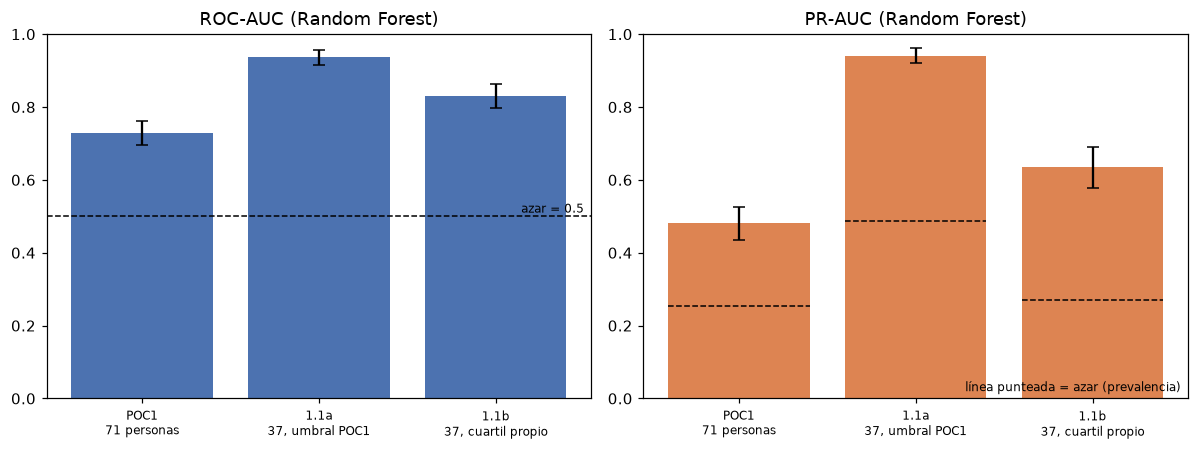

In [7]:
rf_a = results_a["Random Forest"]
settings = [
    ("POC1\n71 personas", rf_71, y_71.mean()),
    ("1.1a\n37, umbral POC1", rf_a, y_37a.mean()),
    ("1.1b\n37, cuartil propio", rf_b, y_37b.mean()),
]

summary = pd.DataFrame({
    label.replace("\n", " "): {"n": n, "prevalencia": f"{prev:.1%}", "F1": fmt(s, "f1"),
                                "ROC-AUC": fmt(s, "roc_auc"), "PR-AUC": fmt(s, "pr_auc")}
    for (label, s, prev), n in zip(settings, [len(y_71), len(y_37a), len(y_37b)])
}).T
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
labels = [s[0] for s in settings]
x = np.arange(len(settings))

roc_m = [s[1]["roc_auc_mean"] for s in settings]
roc_e = [s[1]["roc_auc_std"] for s in settings]
axes[0].bar(x, roc_m, yerr=roc_e, capsize=4, color="#4C72B0")
axes[0].axhline(0.5, color="k", ls="--", lw=1)
axes[0].text(len(x) - 0.5, 0.51, "azar = 0.5", ha="right", fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylim(0, 1); axes[0].set_title("ROC-AUC (Random Forest)")

pr_m = [s[1]["pr_auc_mean"] for s in settings]
pr_e = [s[1]["pr_auc_std"] for s in settings]
axes[1].bar(x, pr_m, yerr=pr_e, capsize=4, color="#DD8452")
for i, s in enumerate(settings):
    axes[1].plot([i - 0.4, i + 0.4], [s[2], s[2]], color="k", ls="--", lw=1)
axes[1].text(len(x) - 0.5, 0.02, "línea punteada = azar (prevalencia)", ha="right", fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylim(0, 1); axes[1].set_title("PR-AUC (Random Forest)")
plt.tight_layout()
plt.show()


# POC 1.2 — ¿El modelo depende de variables que se parecen a la etiqueta?

La etiqueta sale de una medición de Fitbit que ya combina señales del propio reloj. Si las predictoras miden lo
mismo que la etiqueta por otra vía, el modelo puede parecer bueno sin haber aprendido nada útil. Para explorarlo se
**quitan grupos de variables** y se mide cuánto cambia el rendimiento (Random Forest, mismo protocolo):

| Configuración | Qué se quita | Features que quedan |
|---|---|---|
| **Todas** | nada | 22 |
| **Sin pulso ni actividad** | `resting_hr`, `steps`, `sedentary_minutes` (media y desviación) | 16 |
| **Sin variables de sueño** | `minutesAsleep`, `minutesAwake`, `sleep_efficiency`, `minutesToFallAsleep` (media y desviación) | 14 |

**Por qué las dos pruebas:** la etiqueta es el componente de *sueño* del Stress Score de Fitbit (según los datos, ver
`POC1/POC1_FINDINGS.md`). La superposición más directa sería entonces con las variables de sueño. La prueba "sin
pulso ni actividad" se agrega porque el Stress Score completo también usa esas señales.

Se corre en las dos poblaciones: las 71 de POC1 y las 37 con etiqueta real (1.1a).

**Cómo leerlo:** quitar variables casi siempre baja el rendimiento un poco. Lo informativo es *cuánto* baja y hacia
dónde. Si sin un grupo el ROC-AUC se acerca a 0.5 (azar), el modelo dependía de ese grupo.

In [8]:
def cols_of(feature_cols, raw_vars):
    out = []
    for v in raw_vars:
        for suffix in ("_mean", "_std"):
            name = f"{v}{suffix}"
            if v == "minutesAsleep" and suffix == "_std":
                name = "sleep_duration_inconsistency"
            if name in feature_cols:
                out.append(name)
    return out


SLEEP_VARS = ["minutesAsleep", "minutesAwake", "sleep_efficiency", "minutesToFallAsleep"]
HR_ACTIVITY_VARS = ["resting_hr", "steps", "sedentary_minutes"]

populations = {
    "71 personas (POC1)": (X_71, y_71, feats_71),
    "37 personas (1.1a)": (X_37, y_37a, feats_37),
}

ablation_rows = []
ablation_stats = {}
for pop_name, (X_pop, y_pop, feats) in populations.items():
    rf_factory = model_factories(y_pop)["Random Forest"]
    sets = {
        "Todas": feats,
        "Sin pulso ni actividad": [c for c in feats if c not in cols_of(feats, HR_ACTIVITY_VARS)],
        "Sin variables de sueño": [c for c in feats if c not in cols_of(feats, SLEEP_VARS)],
    }
    for set_name, cols in sets.items():
        stats = rf_71 if (pop_name.startswith("71") and set_name == "Todas") else evaluate_model(rf_factory, X_pop[cols], y_pop)
        ablation_stats[(pop_name, set_name)] = stats
        ablation_rows.append({
            "Población": pop_name, "Configuración": set_name, "Features": len(cols),
            "F1": fmt(stats, "f1"), "ROC-AUC": fmt(stats, "roc_auc"), "PR-AUC": fmt(stats, "pr_auc"),
        })

ablation_table = pd.DataFrame(ablation_rows)
ablation_table


,Población,Configuración,Features,F1,ROC-AUC,PR-AUC
0,71 personas (POC1),Todas,22,0.478 ± 0.077,0.728 ± 0.033,0.481 ± 0.046
1,71 personas (POC1),Sin pulso ni actividad,16,0.474 ± 0.045,0.682 ± 0.027,0.441 ± 0.028
2,71 personas (POC1),Sin variables de sueño,14,0.408 ± 0.063,0.664 ± 0.047,0.423 ± 0.083
3,37 personas (1.1a),Todas,22,0.849 ± 0.036,0.936 ± 0.020,0.941 ± 0.021
4,37 personas (1.1a),Sin pulso ni actividad,16,0.756 ± 0.051,0.820 ± 0.037,0.854 ± 0.031
5,37 personas (1.1a),Sin variables de sueño,14,0.803 ± 0.038,0.918 ± 0.023,0.926 ± 0.020


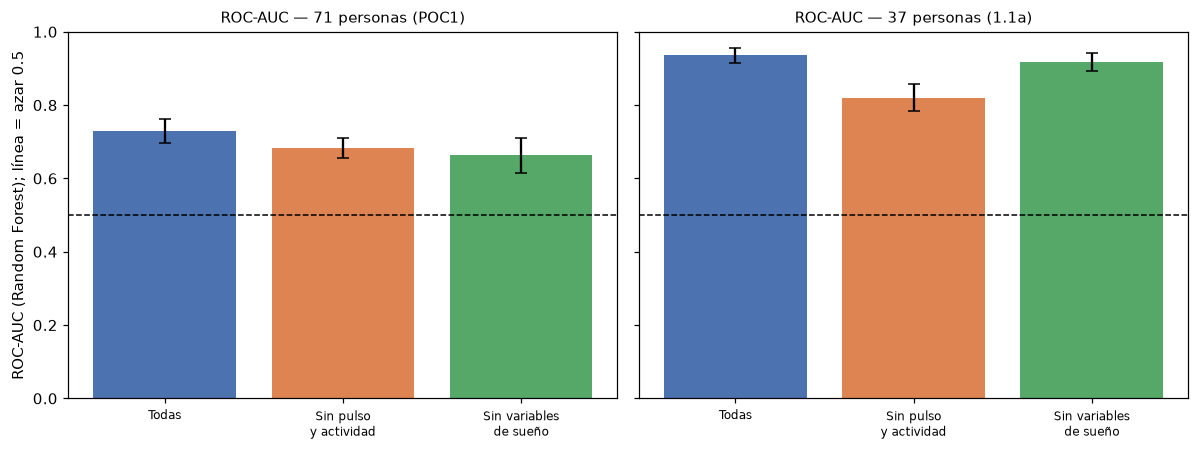

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
set_names = ["Todas", "Sin pulso ni actividad", "Sin variables de sueño"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, pop_name in zip(axes, populations):
    vals = [ablation_stats[(pop_name, s)]["roc_auc_mean"] for s in set_names]
    errs = [ablation_stats[(pop_name, s)]["roc_auc_std"] for s in set_names]
    ax.bar(range(3), vals, yerr=errs, capsize=4, color=colors)
    ax.axhline(0.5, color="k", ls="--", lw=1)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["Todas", "Sin pulso\ny actividad", "Sin variables\nde sueño"], fontsize=8)
    ax.set_title(f"ROC-AUC — {pop_name}", fontsize=10)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("ROC-AUC (Random Forest); línea = azar 0.5")
plt.tight_layout()
plt.show()


## Lectura de los resultados

**POC 1.1 — el resultado cambia, y en dirección contraria a la sospecha inicial.**
- Sin las 34 personas de etiqueta rellenada, Random Forest pasa de ROC-AUC **0.728** (POC1) a **0.936** (1.1a) y a
  **0.830** (1.1b, prevalencia ~27%). En 1.1a los cuatro modelos superan 0.90.
- Frente al azar la mejora es grande en ambas variantes: PR-AUC 0.941 contra 0.486 de azar (1.1a) y 0.635 contra
  0.270 (1.1b).
- Las 34 personas rellenadas **no inflaban** el resultado de POC1: lo **rebajaban**. Estaban en "bajo riesgo" solo por
  no tener dato, y eso mete ruido en la etiqueta. El 0.73 de POC1 es una cota conservadora, no un techo.
- SVM, que en POC1 daba F1 0.088, aquí da 0.862 con clases casi balanceadas. Es consistente con que su fallo en POC1 se
  debiera al desbalance de clases, aunque esta prueba sola no lo demuestra.

**Qué NO significa este resultado:**
- No significa que el modelo prediga calidad de sueño. Predice el puntaje de sueño de Fitbit a partir de otras señales
  del mismo reloj; que eso sea más fácil que predecir sueño real es esperable.
- Con 37 personas el resultado es ruidoso y probablemente optimista: la desviación estándar solo refleja cómo caen las
  particiones, no la incertidumbre de tener solo 37 personas. Además, esas 37 son quienes tienen Stress Score en
  LifeSnaps y podrían no representar a las otras 34 (sesgo de selección).

**POC 1.2 — de qué variables depende el resultado.**
- En las 37 personas, sin pulso ni actividad el ROC-AUC baja de 0.936 a 0.820, mientras que sin las variables de sueño
  casi no cambia (0.918). El modelo se apoya más en pulso y actividad que en las variables de sueño, lo contrario de lo
  que se esperaba dado que la etiqueta es un componente de sueño.
- En las 71 personas, ambas quitas bajan de forma moderada (0.728 → 0.682 sin pulso ni actividad; → 0.664 sin sueño) y
  los rangos se solapan en parte.
- Ninguna quita lleva al azar (0.5): hay señal en ambos grupos. Como las variables están correlacionadas entre sí, unas
  pueden sustituir a otras, y esta prueba no aísla el aporte individual de cada variable.
- Una explicación posible, no verificada: como el puntaje forma parte de un score que también incorpora señales
  cardíacas y de actividad, no sería independiente de ellas.



## Notas metodológicas

- Todo usa el mismo protocolo que POC1, con la misma semilla; los resultados son reproducibles.
- Con 37 personas, la varianza entre particiones es alta. La desviación estándar de cada métrica ya la refleja: dos
  configuraciones cuyos rangos ± desviación se solapan no se pueden distinguir.
- Estos análisis no cambian el modelo elegido ni la metodología de POC1. Sirven para saber **cuánto confiar** en sus
  números mientras la etiqueta siga siendo el proxy de Fitbit.
